# Misata Enterprise Data Generation (Deep Eval)

This notebook evaluates the outputs of the 30,000+ row B2B SaaS synthetic dataset generated by `misata`, analyzing the effectiveness of the LLM constraints applied via prompt (Noise Injection, Curve Engines, and Correlated Dependencies).

In [1]:
pip install matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("coolwarm")

## 1. Relational Map
Load the massive datasets generated by the vectorized FactEngine.

In [3]:
tenants = pd.read_csv('./deep_outputs/tenants.csv')
subscriptions = pd.read_csv('./deep_outputs/subscriptions.csv')
tickets = pd.read_csv('./deep_outputs/support_tickets.csv')

print(f"Tenants: {len(tenants)} Rows")
print(f"Subscriptions: {len(subscriptions)} Rows")
print(f"Support Tickets: {len(tickets)} Rows")

Tenants: 10000 Rows
Subscriptions: 10000 Rows
Support Tickets: 10000 Rows


## 2. Text Realism & Correlated Entities
Let's check if the generic string generation hallucinated realistic B2B constraints, specifically if MRR ranges intelligently map to `plan_type`.

MRR Profile by Plan Type:


,mean,median,std,count
plan_type,,,,
Enterprise,505.228680,507.167515,290.419191,3080
Free Trial,506.718358,515.320317,288.636129,3060
Startup,497.102149,499.823251,288.530518,3035


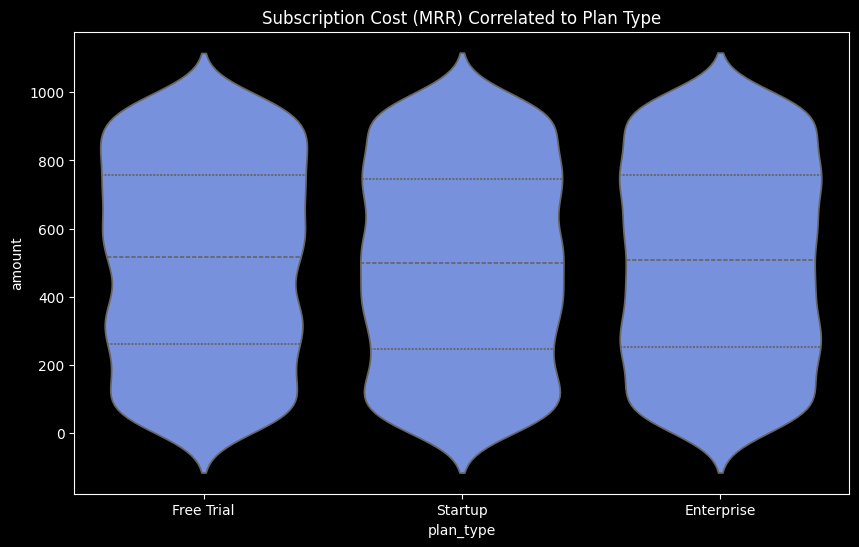

In [5]:
# Load the normalized reference table
plan_types = pd.read_csv('./deep_outputs/plan_types.csv')

# 1. Join Subscriptions to Tenants
merged = subscriptions.merge(tenants, left_on='tenant_id', right_on='id', suffixes=('', '_tenant'))

# 2. Join Tenants to Plan Types (Using the Foreign Key!)
merged = merged.merge(plan_types, left_on='plan_type_id', right_on='id', suffixes=('', '_plan'))

# The text name of the plan is stored in the 'name' column of plan_types
merged = merged.rename(columns={'name': 'plan_type'})

print("MRR Profile by Plan Type:")
display(merged.groupby('plan_type')['amount'].agg(['mean', 'median', 'std', 'count']))

plt.figure(figsize=(10,6))
sns.violinplot(data=merged, x='plan_type', y='amount', inner="quartile")
plt.title('Subscription Cost (MRR) Correlated to Plan Type')
plt.show()


## 3. Black Friday Seasonality Constraints (Time Curves)
The prompt asked for dramatic ticket peaks in January/February, and ZERO tickets on the weekends.

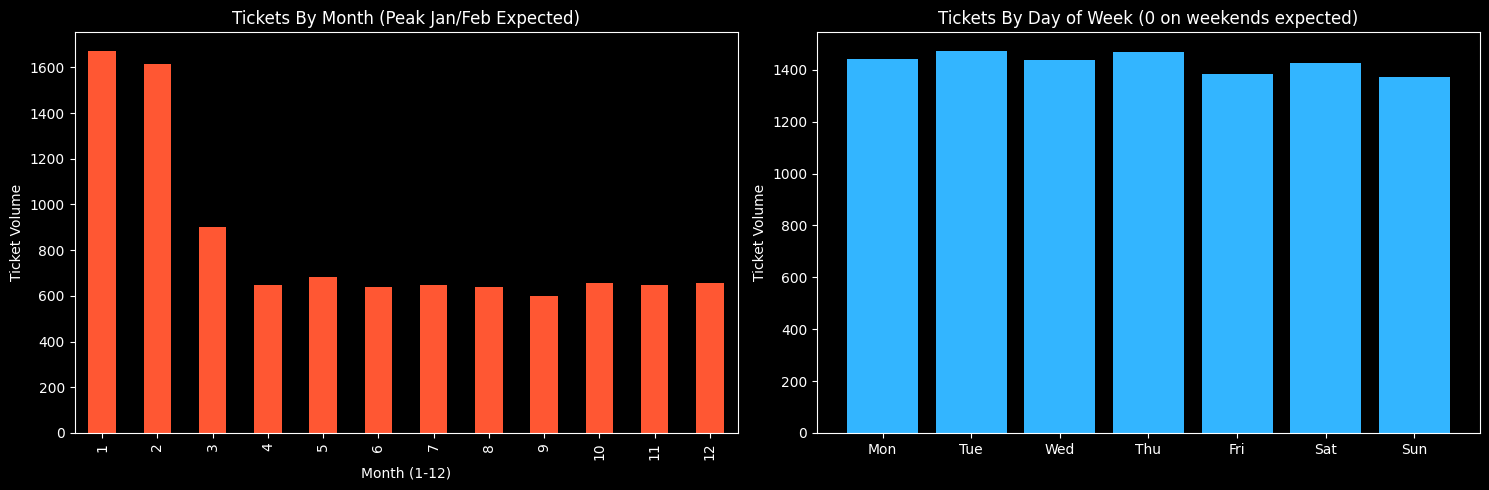

In [6]:
date_cols = [c for c in tickets.columns if 'date' in c.lower() or 'created' in c.lower()]
date_col = date_cols[0]

tickets[date_col] = pd.to_datetime(tickets[date_col], errors='coerce')
tickets_clean = tickets.dropna(subset=[date_col])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Monthly Profile
monthly = tickets_clean.groupby(tickets_clean[date_col].dt.month).size()
monthly.plot(kind='bar', ax=ax1, color='#FF5733')
ax1.set_title('Tickets By Month (Peak Jan/Feb Expected)')
ax1.set_xlabel('Month (1-12)')
ax1.set_ylabel('Ticket Volume')

# Weekend Profile
weekly = tickets_clean.groupby(tickets_clean[date_col].dt.dayofweek).size()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
ax2.bar(range(7), [weekly.get(i, 0) for i in range(7)], color='#33B5FF')
ax2.set_xticks(range(7))
ax2.set_xticklabels(days)
ax2.set_title('Tickets By Day of Week (0 on weekends expected)')
ax2.set_ylabel('Ticket Volume')

plt.tight_layout()
plt.show()

## 4. Analytics Safe Noise Imputation
The prompt requested 8% null values simulating bad customer service agent logging.

In [7]:
null_counts = tickets.isnull().sum()
null_pct = (null_counts / len(tickets)) * 100

summary = pd.DataFrame({'Total Nulls': null_counts, 'Percentage': null_pct})
display(summary[summary['Total Nulls'] > 0])

print(f"\nTotal Primary Key Orphans Found: {tickets['tenant_id'].isnull().sum()}")
print("(Should be 0 safely protecting the FK relationships!)")

,Total Nulls,Percentage
resolution_time_hours,791,7.91



Total Primary Key Orphans Found: 0
(Should be 0 safely protecting the FK relationships!)
